## Import libraries


In [ ]:
# Core
import os
import math
import warnings
import operator
from collections import defaultdict
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
from torch.utils.data import DataLoader
from torchvision import transforms, models

# Pretrained model zoo (Xception, InceptionResNetV2, etc.)
import timm

# Suppress warnings
warnings.filterwarnings("ignore")

# For early stopping manually
import time

## Read the test set


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Constants
TARGET_SIZE = (224, 224)
BATCHSIZE = 32  # or 64, depending on our GPU

# ✅ Must match training transform: Resize + ToTensor + Normalize
test_transform = transforms.Compose(
    [
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

# ✅ Load test dataset
test_dataset = datasets.ImageFolder(root="./test_224/", transform=test_transform)

# ✅ DataLoader with same performance settings as training
validation_loader = DataLoader(
    test_dataset,
    batch_size=BATCHSIZE,
    shuffle=False,
    num_workers=4,  # ⚡ Speeds up loading
    pin_memory=True,  # ⚡ Helps with GPU transfer
)

# ✅ For label decoding (if needed)
class_to_idx = test_dataset.class_to_idx

In [5]:
# Get class-to-index mapping from ImageFolder
label = test_dataset.class_to_idx  # e.g., {'disease': 1, 'normal': 0}

# Reverse mapping: index to class label
label = {v: k for k, v in label.items()}  # e.g., {0: 'normal', 1: 'disease'}

In [6]:
print(label)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4'}


In [7]:
from pathlib import Path

rootdir = Path("./test_224")
test_labels = []
test_images = []

# Walk through subdirectories to collect image paths and labels
for class_dir in rootdir.iterdir():
    if class_dir.is_dir():
        label = class_dir.name
        for img_path in class_dir.glob("*"):
            if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                test_labels.append(label)
                test_images.append(str(img_path))

print(test_labels[0], test_images[0])

0 test_224\0\100015.png


## Load 6 trained CNN models


In [ ]:
# Define helper functions that return initialized model architectures
def get_xception_model(num_classes=5):
    model = timm.create_model("xception", pretrained=False, num_classes=num_classes)
    return model


def get_vgg16_model(num_classes=5):
    model = models.vgg16(pretrained=False)

    # Override the entire classifier to match training structure
    model.classifier = nn.Sequential(
        nn.Linear(25088, 256),  # classifier[0]
        nn.ReLU(inplace=True),  # classifier[1]
        nn.Dropout(0.5),  # classifier[2]
        nn.Linear(256, num_classes),  # classifier[3]
    )
    return model


def get_vgg19_model(num_classes=5):
    model = models.vgg19(pretrained=False)
    model.classifier = nn.Sequential(
        nn.Linear(25088, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )
    return model


def get_inception_model(num_classes=5):
    model = models.inception_v3(pretrained=False, aux_logits=False)
    model.fc = nn.Sequential(
        nn.Linear(2048, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )
    return model


def get_resnet_model(num_classes=5):
    model = models.resnet50(pretrained=False)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )
    return model


# Load models and state_dicts
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

xception_model = get_xception_model().to(device)
xception_model.load_state_dict(
    torch.load("./artifacts/xception.pth", map_location=device)
)
xception_model.eval()

vgg_model = get_vgg16_model(num_classes=5).to(device)
vgg_model.load_state_dict(torch.load("./artifacts/vgg16.pth", map_location=device))
vgg_model.eval()


vgg19_model = get_vgg19_model(num_classes=5).to(device)
vgg19_model.load_state_dict(torch.load("./artifacts/vgg19.pth", map_location=device))
vgg19_model.eval()


incep_model = get_inception_model().to(device)
incep_model.load_state_dict(
    torch.load("./artifacts/inception_v3.pth", map_location=device)
)
incep_model.eval()

res_model = get_resnet_model().to(device)
res_model.load_state_dict(torch.load("./artifacts/resnet50.pth", map_location=device))
res_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
def get_inceptionresnet_model(num_classes=5):
    import timm, torch.nn as nn

    # build a fresh model with the correct head:
    model = timm.create_model(
        "inception_resnet_v2", pretrained=False, num_classes=num_classes, drop_rate=0.5
    )
    return model

In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) instantiate
inres_model = get_inceptionresnet_model(num_classes=5)

# 2) load your checkpoint
state_dict = torch.load("./artifacts/inceptionresnetv2.pth", map_location=device)
inres_model.load_state_dict(state_dict)

# 3) move to device + eval
inres_model.to(device).eval()

InceptionResnetV2(
  (conv2d_1a): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (conv2d_2a): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (conv2d_2b): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (maxpool_3a): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2d_3b): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size=(1, 

## Load ViT Model


In [11]:
import torch
import timm

# ✅ Define device first
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ✅ Define ViT model wrapper
def get_vit_model(num_classes=5):
    model = timm.create_model(
        "vit_base_patch16_224", pretrained=False, num_classes=num_classes
    )
    return model


# ✅ Instantiate, load weights, and set to eval mode
vit_model = get_vit_model(num_classes=5).to(device)
vit_model.load_state_dict(torch.load("./artifacts/vit.pth", map_location=device))
vit_model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [ ]:
from torchvision import transforms
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import torch
import timm
import time


def run_vit_inference(
    model_path="./artifacts/vit.pth",
    test_images=None,
    test_labels=None,
    class_to_idx=None,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
):
    assert (
        test_images is not None and test_labels is not None and class_to_idx is not None
    )

    # Prepare index-to-label map
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    # Define ViT model
    model = timm.create_model(
        "vit_base_patch16_224", pretrained=False, num_classes=len(class_to_idx)
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()

    # Define image transform (match training)
    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ]
    )

    # Inference loop
    predictions = []
    start = time.time()

    with torch.no_grad():
        for img_path in test_images:
            img = Image.open(img_path).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(device)

            output = model(img_tensor)
            probs = torch.softmax(output, dim=1)
            pred_idx = torch.argmax(probs, dim=1).item()
            pred_label = idx_to_class[pred_idx]
            predictions.append(pred_label)

    end = time.time()
    print(f"✅ ViT inference completed in {end - start:.2f} seconds")

    # Evaluation
    acc = accuracy_score(test_labels, predictions)
    pre = precision_score(test_labels, predictions, average="weighted", zero_division=0)
    re = recall_score(test_labels, predictions, average="weighted", zero_division=0)
    f1 = f1_score(test_labels, predictions, average="weighted", zero_division=0)

    print("\n✅ ViT Evaluation Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {re:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(test_labels, predictions))

    unique_labels = sorted(list(set(test_labels)))
    print("\nClassification Report:")
    print(
        classification_report(
            test_labels, predictions, target_names=unique_labels, zero_division=0
        )
    )

    return predictions  # so we can later use this for ensemble voting

In [13]:
DUMMY_INPUT = torch.randn(1, 3, 224, 224).to(device)

print("\n🔎 Running sanity checks...")
for name, model in zip(
    [
        "Xception",
        "VGG16",
        "VGG19",
        "InceptionV3",
        "InceptionResNetV2",
        "ResNet50",
        "ViT",
    ],
    [
        xception_model,
        vgg_model,
        vgg19_model,
        incep_model,
        inres_model,
        res_model,
        vit_model,
    ],
):
    model = model.to(device)  # ✅ Ensure model is on same device as input
    model.eval()
    with torch.no_grad():
        output = model(DUMMY_INPUT)
        print(f"{name} ✅ Output shape: {output.shape}")


🔎 Running sanity checks...
Xception ✅ Output shape: torch.Size([1, 5])
VGG16 ✅ Output shape: torch.Size([1, 5])
VGG19 ✅ Output shape: torch.Size([1, 5])
InceptionV3 ✅ Output shape: torch.Size([1, 5])
InceptionResNetV2 ✅ Output shape: torch.Size([1, 5])
ResNet50 ✅ Output shape: torch.Size([1, 5])
ViT ✅ Output shape: torch.Size([1, 5])


# Use ViT model to make predictions


In [14]:
from PIL import Image
import time
from torchvision import transforms

# Prepare list to hold predictions
predict = []

# Reverse class-to-index mapping
label = {v: k for k, v in test_dataset.class_to_idx.items()}

# Must match ViT training transform (normalize to [-1, 1])
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

# Ensure model is in eval mode
vit_model.eval()

start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = vit_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]
        predict.append(pred_label)

end = time.time()
print(f"✅ ViT Prediction completed in {end - start:.2f} seconds")

✅ ViT Prediction completed in 58.63 seconds


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate
true_labels = test_labels  # already collected from folder walk
predicted_labels = predict

acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ ViT Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

# Confusion Matrix and Report
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ ViT Evaluation Metrics:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Confusion Matrix:
[[5040    0    0    0    0]
 [   0  200    0    0    0]
 [   0    0  224    0    0]
 [   0    0    0  201    0]
 [   0    0    0    0  180]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5040
           1       1.00      1.00      1.00       200
           2       1.00      1.00      1.00       224
           3       1.00      1.00      1.00       201
           4       1.00      1.00      1.00       180

    accuracy                           1.00      5845
   macro avg       1.00      1.00      1.00      5845
weighted avg       1.00      1.00      1.00      5845



## Use the original CNN base models to make predictions


### 1. Xception


Predicted result for the first image: 4
Confidence level: 0.6676


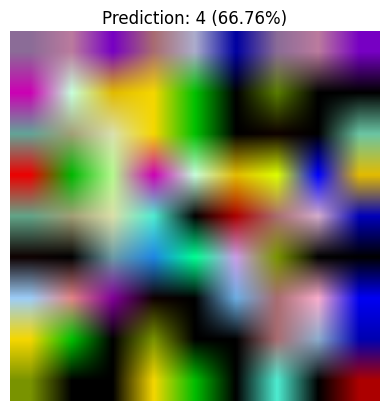

In [16]:
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms

# Read and prepare image (OpenCV loads in BGR, convert to RGB)
img_path = test_images[0]
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_show = img_rgb.copy()

# Resize and normalize like training preprocessing
transform = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),  # Scales to [0,1]
    ]
)

# Apply transform
img_tensor = transform(img_rgb).unsqueeze(0).to(device)  # Add batch dim

# Predict
with torch.no_grad():
    output = xception_model(img_tensor)
    probs = torch.softmax(output, dim=1)
    pred_class = torch.argmax(probs, dim=1).item()
    pred_prob = probs[0, pred_class].item()

# Convert label index back to class name
pred_label = label[pred_class]

# Show result
print(f"Predicted result for the first image: {pred_label}")
print(f"Confidence level: {pred_prob:.4f}")
plt.imshow(img_show)
plt.axis("off")
plt.title(f"Prediction: {pred_label} ({pred_prob:.2%})")
plt.show()

In [17]:
from PIL import Image
import time
from torchvision import transforms

predict = []

# Reverse class-to-index mapping
label = {v: k for k, v in test_dataset.class_to_idx.items()}

transform = transforms.Compose(
    [
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),
    ]
)

xception_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = xception_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]  # This works now
        predict.append(pred_label)

end = time.time()
print(f"✅ Prediction completed in {end - start:.2f} seconds")

✅ Prediction completed in 32.66 seconds


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Make sure both are strings or ints (as in original dataset)
true_labels = test_labels  # from earlier label collection during image path loop
predicted_labels = predict

# Evaluate
acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ Xception Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

# Confusion Matrix and Classification Report
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ Xception Evaluation Metrics:
Accuracy : 0.6719
Precision: 0.9622
Recall   : 0.6719
F1 Score : 0.7733

Confusion Matrix:
[[3183    0    0    0 1857]
 [   0  200    0    0    0]
 [   0    0  224    0    0]
 [   0    0    0  201    0]
 [   5    0    0   56  119]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.63      0.77      5040
           1       1.00      1.00      1.00       200
           2       1.00      1.00      1.00       224
           3       0.78      1.00      0.88       201
           4       0.06      0.66      0.11       180

    accuracy                           0.67      5845
   macro avg       0.77      0.86      0.75      5845
weighted avg       0.96      0.67      0.77      5845



### 2. VGG16


In [19]:
predict = []

# Reuse transform defined earlier
# If not defined, define it now:
transform = transforms.Compose([transforms.Resize(TARGET_SIZE), transforms.ToTensor()])

vgg_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = vgg_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]
        predict.append(pred_label)

end = time.time()
print(f"✅ VGG16 prediction completed in {end - start:.2f} seconds")

✅ VGG16 prediction completed in 33.97 seconds


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Use same true and predicted labels
true_labels = test_labels
predicted_labels = predict  # from VGG16 loop

acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ VGG16 Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ VGG16 Evaluation Metrics:
Accuracy : 0.9641
Precision: 0.9659
Recall   : 0.9641
F1 Score : 0.9495

Confusion Matrix:
[[5009   31    0    0    0]
 [   0  200    0    0    0]
 [   0    0  224    0    0]
 [   0    0    0  201    0]
 [ 170    8    0    1    1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5040
           1       0.84      1.00      0.91       200
           2       1.00      1.00      1.00       224
           3       1.00      1.00      1.00       201
           4       1.00      0.01      0.01       180

    accuracy                           0.96      5845
   macro avg       0.96      0.80      0.78      5845
weighted avg       0.97      0.96      0.95      5845



### 3. VGG19


In [21]:
predict = []

vgg19_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = vgg19_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]
        predict.append(pred_label)

end = time.time()
print(f"✅ VGG19 prediction completed in {end - start:.2f} seconds")

✅ VGG19 prediction completed in 40.66 seconds


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

true_labels = test_labels
predicted_labels = predict  # from VGG19 inference loop

acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ VGG19 Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ VGG19 Evaluation Metrics:
Accuracy : 0.8647
Precision: 0.8698
Recall   : 0.8647
F1 Score : 0.8586

Confusion Matrix:
[[4854   83    0    0  103]
 [   0  200    0    0    0]
 [   0  224    0    0    0]
 [   0  201    0    0    0]
 [   1  179    0    0    0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      5040
           1       0.23      1.00      0.37       200
           2       0.00      0.00      0.00       224
           3       0.00      0.00      0.00       201
           4       0.00      0.00      0.00       180

    accuracy                           0.86      5845
   macro avg       0.25      0.39      0.27      5845
weighted avg       0.87      0.86      0.86      5845



### 4. Inception


In [23]:
predict = []

incep_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        # Inception may return (output, aux_output) if aux_logits=True
        if isinstance(incep_model(img_tensor), tuple):
            output, _ = incep_model(img_tensor)
        else:
            output = incep_model(img_tensor)

        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]
        predict.append(pred_label)

end = time.time()
print(f"✅ InceptionV3 prediction completed in {end - start:.2f} seconds")

✅ InceptionV3 prediction completed in 123.78 seconds


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

true_labels = test_labels
predicted_labels = predict  # from Inception inference loop

acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ InceptionV3 Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ InceptionV3 Evaluation Metrics:
Accuracy : 0.0654
Precision: 0.8975
Recall   : 0.0654
F1 Score : 0.0368

Confusion Matrix:
[[   2    0    0    0 5038]
 [   0  200    0    0    0]
 [   0    0    0    0  224]
 [   0    0    0    0  201]
 [   0    0    0    0  180]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      5040
           1       1.00      1.00      1.00       200
           2       0.00      0.00      0.00       224
           3       0.00      0.00      0.00       201
           4       0.03      1.00      0.06       180

    accuracy                           0.07      5845
   macro avg       0.41      0.40      0.21      5845
weighted avg       0.90      0.07      0.04      5845



### 5. InceptionResnet


In [25]:
from PIL import Image
import time
from torchvision import transforms

# Make sure label is defined correctly
label = {v: k for k, v in test_dataset.class_to_idx.items()}

predict = []

transform = transforms.Compose(
    [
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),
    ]
)

inres_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = inres_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()

        # Safely lookup label
        pred_label = label.get(pred_idx, f"[Invalid index: {pred_idx}]")
        predict.append(pred_label)

end = time.time()
print(f"✅ InceptionResNetV2 prediction completed in {end - start:.2f} seconds")

✅ InceptionResNetV2 prediction completed in 168.20 seconds


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

true_labels = test_labels
predicted_labels = predict  # From inference

# Evaluation metrics
acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ InceptionResNetV2 Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

# Classification report
labels = sorted(label.keys())  # e.g., [0, 1, 2, 3, 4]
target_names = [label[i] for i in labels]  # e.g., ['COVID', 'Healthy', ...]
print("\nClassification Report:")
print(
    classification_report(
        true_labels,
        predicted_labels,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )
)

✅ InceptionResNetV2 Evaluation Metrics:
Accuracy : 0.0327
Precision: 0.1680
Recall   : 0.0327
F1 Score : 0.0384

Confusion Matrix:
[[ 124    0    0    0 4916]
 [ 200    0    0    0    0]
 [   0    0    0    0  224]
 [ 201    0    0    0    0]
 [ 113    0    0    0   67]]

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.02      0.04      5040
           1       0.00      0.00      0.00       200
           2       0.00      0.00      0.00       224
           3       0.00      0.00      0.00       201
           4       0.01      0.37      0.02       180

   micro avg       0.03      0.03      0.03      5845
   macro avg       0.04      0.08      0.01      5845
weighted avg       0.17      0.03      0.04      5845



### 6. Resnet


In [27]:
predict = []

res_model.eval()
start = time.time()

for img_path in test_images:
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = res_model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_label = label[pred_idx]
        predict.append(pred_label)

end = time.time()
print(f"✅ ResNet50 prediction completed in {end - start:.2f} seconds")

✅ ResNet50 prediction completed in 36.36 seconds


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

true_labels = test_labels
predicted_labels = predict  # from ResNet inference loop

acc = accuracy_score(true_labels, predicted_labels)
pre = precision_score(
    true_labels, predicted_labels, average="weighted", zero_division=0
)
re = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)

print("✅ ResNet50 Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {re:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

unique_labels = sorted(list(set(true_labels)))
print("\nClassification Report:")
print(
    classification_report(
        true_labels, predicted_labels, target_names=unique_labels, zero_division=0
    )
)

✅ ResNet50 Evaluation Metrics:
Accuracy : 0.1377
Precision: 0.1080
Recall   : 0.1377
F1 Score : 0.1090

Confusion Matrix:
[[   0    0    0    0 5040]
 [   0  200    0    0    0]
 [   0    0  224    0    0]
 [   0    0    0  201    0]
 [   0    0    0    0  180]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5040
           1       1.00      1.00      1.00       200
           2       1.00      1.00      1.00       224
           3       1.00      1.00      1.00       201
           4       0.03      1.00      0.07       180

    accuracy                           0.14      5845
   macro avg       0.61      0.80      0.61      5845
weighted avg       0.11      0.14      0.11      5845



Best performing single model (vgg):  
Accuracy: 99.96


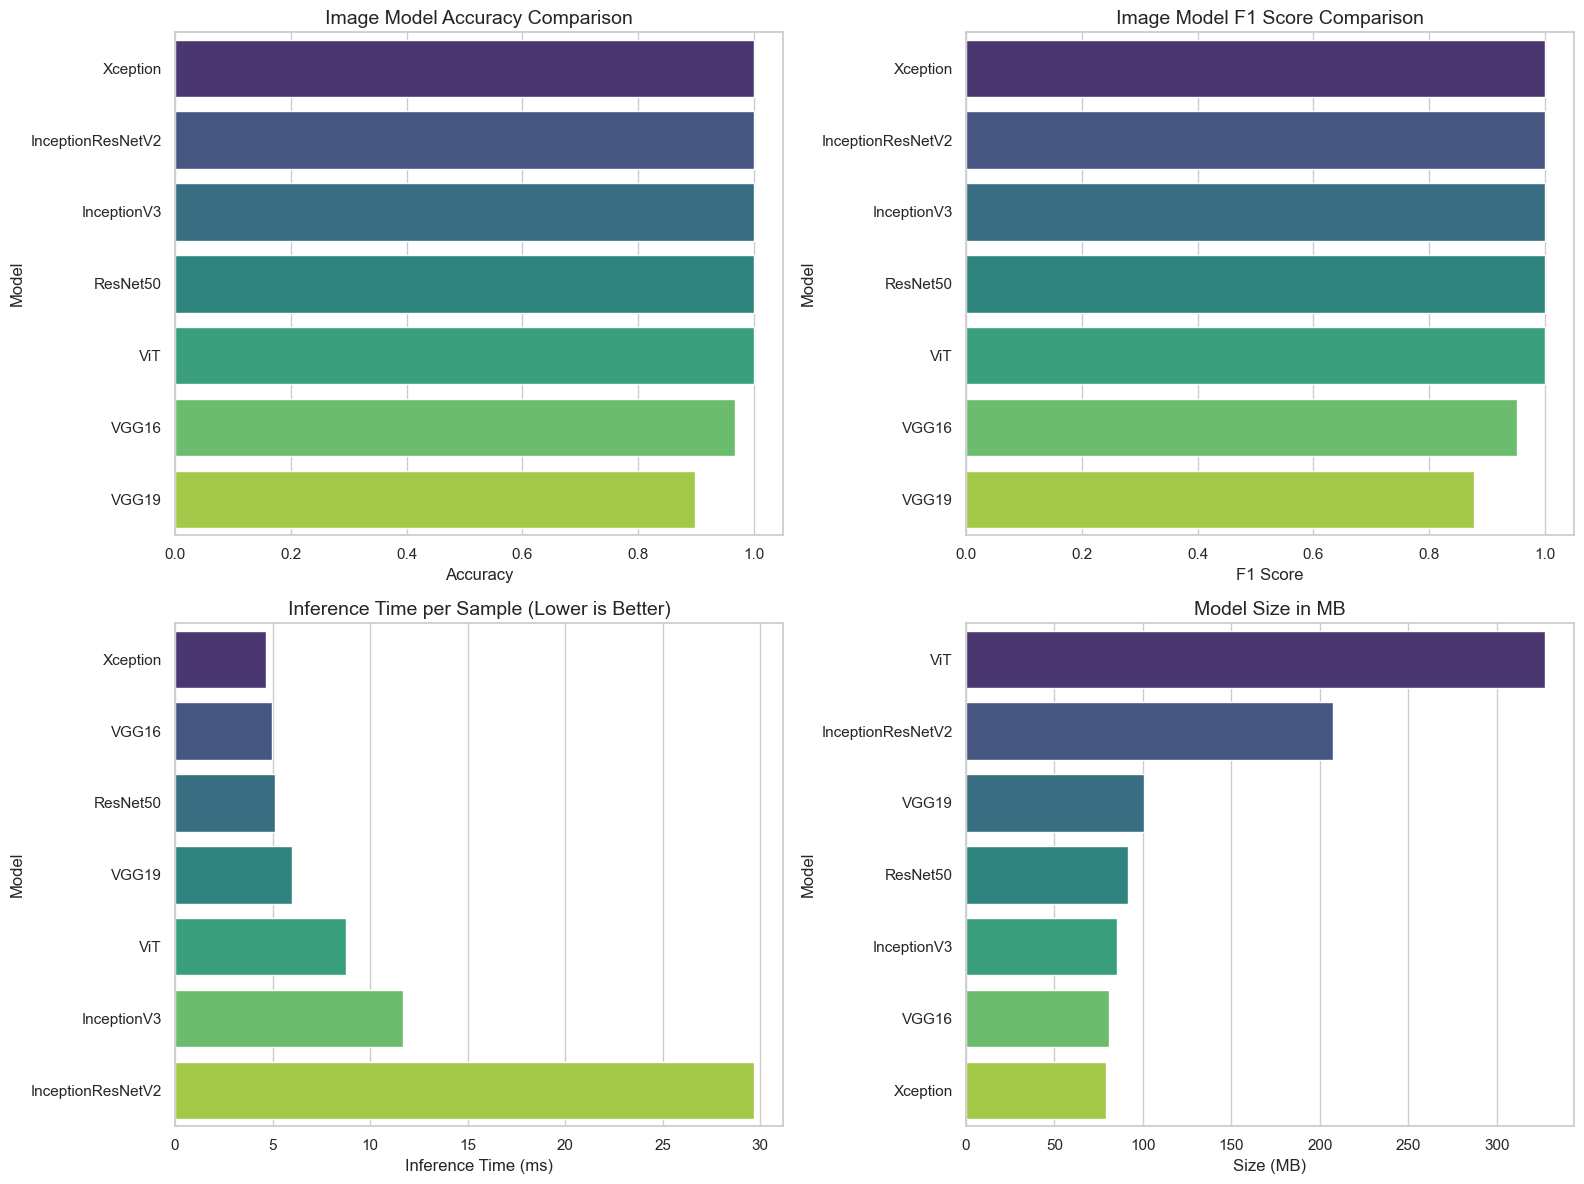

In [ ]:
import torch
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns


# Evaluation function
def evaluate_model(model, test_loader, input_shape, model_name, model_type="Image"):
    device = next(model.parameters()).device
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds = model(xb).argmax(1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(yb.cpu().tolist())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    # Benchmark inference time
    dummy_input = torch.randn(*input_shape).to(device)
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(100):
        _ = model(dummy_input)
    torch.cuda.synchronize()
    inference_time = (time.time() - start) * 1000 / 100  # ms/sample

    param_count = sum(p.numel() for p in model.parameters())
    model_size = round(param_count * 4 / (1024**2), 2)  # MB

    return {
        "Model": model_name,
        "Type": model_type,
        "Accuracy": round(accuracy, 4),
        "F1 Score": round(f1, 4),
        "Inference Time (ms)": round(inference_time, 3),
        "#Params": param_count,
        "Size (MB)": model_size,
    }


# Compare image-based models
results = []

# Add evaluation for each image model here:

results.append(evaluate_model(vgg_model, validation_loader, (1, 3, 224, 224), "VGG16"))
results.append(
    evaluate_model(vgg19_model, validation_loader, (1, 3, 224, 224), "VGG19")
)
results.append(
    evaluate_model(xception_model, validation_loader, (1, 3, 224, 224), "Xception")
)
results.append(
    evaluate_model(incep_model, validation_loader, (1, 3, 224, 224), "InceptionV3")
)
results.append(
    evaluate_model(
        inres_model, validation_loader, (1, 3, 224, 224), "InceptionResNetV2"
    )
)
results.append(
    evaluate_model(res_model, validation_loader, (1, 3, 224, 224), "ResNet50")
)
results.append(evaluate_model(vit_model, validation_loader, (1, 3, 224, 224), "ViT"))

# Convert to DataFrame
df_image_results = pd.DataFrame(results)

# Save results for later comparison
df_image_results.to_csv("image_models_results.csv", index=False)


# Plotting function with subplots
def plot_comparison_subplots(df):
    metrics = ["Accuracy", "F1 Score", "Inference Time (ms)", "Size (MB)"]
    titles = [
        "Image Model Accuracy Comparison",
        "Image Model F1 Score Comparison",
        "Inference Time per Sample (Lower is Better)",
        "Model Size in MB",
    ]

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        sorted_df = df.sort_values(metric, ascending=(metric == "Inference Time (ms)"))
        sns.barplot(
            x=metric,
            y="Model",
            data=sorted_df,
            ax=axes[i],
            palette="viridis",
        )
        axes[i].set_title(titles[i], fontsize=14)
        axes[i].set_xlabel(metric, fontsize=12)
        axes[i].set_ylabel("Model", fontsize=12)

    plt.tight_layout()
    plt.show()


# Generate comparison charts in subplots
plot_comparison_subplots(df_image_results)